   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6409/6409 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9981 - loss: 0.0094 - val_accuracy: 0.9996 - val_loss: 0.0025
Epoch 2/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9996 - val_loss: 0.0026
Epoch 3/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9996 - val_loss: 0.0023
Epoch 4/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 0.9996 - val_loss: 0.0023
Epoch 5/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 0.9996 - val_loss: 0.0024
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

Evaluation Metrics
Precision: 0.798
Recall: 0.8061
F1-Score: 0.802


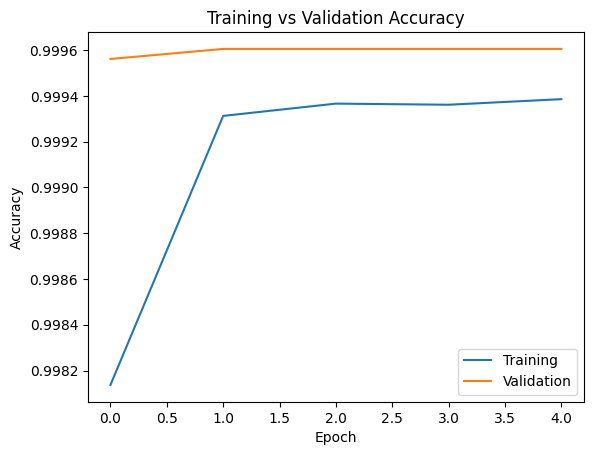

In [ ]:

# riya_varma_23070521118

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Load dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data = pd.read_csv(url)

print(data.head())
print("Dataset Shape:", data.shape)

# 2. Separate features and target
X = data.drop("Class", axis=1)
y = data["Class"]

# 3. Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Build Deep Neural Network
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# 6. Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 7. Train model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# 8. Predict
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).ravel()

# 9. Evaluation
print("\nEvaluation Metrics")
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-Score:", round(f1_score(y_test, y_pred), 4))

# 10. Accuracy graph
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()